# Extrapolate end-to-end (intelligrate.extrapolate)

This notebook runs the full `intelligrate.extrapolate` workflow using the **Python API**:
1) nested CV training (OOF outputs)
2) full fit (final model artifact)
3) full predict (new samples + optional evaluation on paired subset)

Outputs are written to `results/`.

It uses the example data in `data/`.


## Install (pip)
If you are running this notebook outside the repo, install with pip.
If you are inside this repo, install in editable mode so local edits are picked up.


In [1]:
from pathlib import Path
import sys
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pwd

'/Users/meyeanni/Desktop/git_sourdough/Intelligrate/docs/notebooks'

install intelligrate (if not yet installed):


In [ ]:
# Uncomment if needed:
# !pip install "intelligrate @ git+https://github.com/ORG/REPO.git@vX.Y.Z"



In [3]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists():
            return p
    raise FileNotFoundError('Could not find repo root (pyproject.toml)')

repo_root = find_repo_root(Path.cwd())

# Ensure local package imports work without installation
sys.path.insert(0, str(repo_root / 'src'))

results_dir = repo_root / 'results'
results_dir.mkdir(parents=True, exist_ok=True)

print('Repo root:', repo_root)
print('Results dir:', results_dir)


Repo root: /Users/meyeanni/Desktop/git_sourdough/Intelligrate
Results dir: /Users/meyeanni/Desktop/git_sourdough/Intelligrate/results


## Load inputs
- `X_kmers.tsv`: paired samples (k-mers)
- `X_kmers_full.tsv`: all samples (paired + unpaired, for extrapolation)
- `Y_kos.tsv`: KO profiles for paired samples
- `ko_to_superclass.tsv`: KO -> pathway/superclass mapping, optional


In [4]:
X_full = pd.read_csv(repo_root / 'data' / 'X_kmers_full.tsv', sep='	', index_col=0)
X = pd.read_csv(repo_root / 'data' / 'X_kmers.tsv', sep='	', index_col=0)
Y = pd.read_csv(repo_root / 'data' / 'Y_kos.tsv', sep='	', index_col=0)

print('X_full:', X_full.shape)
print('X:', X.shape)
print('Y:', Y.shape)


X_full: (610, 12340)
X: (95, 12340)
Y: (95, 4211)


## Parameters
Parameters that we define here correspond to what can be found in the **defaults** as `configs/default.yaml`, but now we expose them here in the notebook for easier editing.


If you want to see every parameter and full explanations, also check:
- `docs/TUTORIAL_extrapolate.md`
- `src/intelligrate/extrapolate/train.py` and `src/intelligrate/extrapolate/cv_knn.py`


In [5]:
# ---- Data file names (used by the training API) ----
data_cfg = {
    'x_full': 'X_kmers_full.tsv',
    'x': 'X_kmers.tsv',
    'y': 'Y_kos.tsv',
    'picrust2': 'picrust2_kos.tsv', # optional for comparison
    'ko_to_superclass': 'ko_to_superclass.tsv', # optional for pathway RMSE
}

# ---- Cross-validation settings ----
cv_cfg = {
    # outer_splits/inner_splits: more splits = slower but more stable estimates
    'outer_splits': 5,
    'inner_splits': 3,
    'seed': 0,
    # informed_splits: use metadata to form splits (False by default)
    'informed_splits': False,
}

# ---- X embedding (k-mer -> low-dim) ----
embed_cfg = {
    # min_prev_x_abs: drop k-mers present in fewer samples than this
    'min_prev_x_abs': 14,
    # pseudocount_x: added before CLR
    'pseudocount_x': 0.5,
    # n_components: SVD dimensions for the k-mer embedding (X space)
    'n_components': 128,
}

# ---- Model / prediction settings ----
model_cfg = {
    # min_prev_y_abs: drop KOs seen in fewer samples than this
    'min_prev_y_abs': 1,
    # y_detect_threshold: detection threshold in TSS space
    'y_detect_threshold': 3000.0,
    # pseudocount_y: added before CLR
    'pseudocount_y': 0.5 / 1e6,

    # KNN hyperparameters (grid for nested CV)
    'neigh_k_grid': [20, 24, 28, 32],
    'tau_mult_grid': [0.5, 1.0, 2.0, 4.0],
    'lam_grid': [0.0],
    'y_latent_k_grid': [0, 10, 20],

    # Metric learning
    'use_metric_learning': True,
    'metric_max_pairs': 5000,
    'metric_ridge_grid': [1.0, 2.5, 5.0],

    # Out-of-distribution shrinkage
    'ood_shrink': True,
    'ood_shrink_inner': True,
    'ood_lam_base': 0.7,
    'ood_lam_cap': 0.5,
    'ood_tau_inflate': False,
}

# ---- Objective weights ----
objective_cfg = {
    # w_dm is the primary objective (Aitchison DM Spearman)
    'w_dm': 1.0,
    'w_wclr': 0.0,
    'w_pw_rmse': 0.0,
    'w_softf1': 0.0,
    'w_jsd': 0.0,
}

# ---- Precision/recall settings ----
prf_cfg = {
    'prf_thresh': 1.0e-6,
    'prf_weight': 'binary', 
}

# ---- Optional metrics ----
metrics_cfg = {
    'compute_wclr': True,
    'compute_jsd': True,
    'compute_pathway_rmse': True,
    'pathway_rmse_per_group': True,
    'pathway_rmse_log1p': True,
}

# ---- Score settings (for the optional global OOF DM check) ----
score_cfg = {
    'min_prev_y_abs': 1,
    'y_detect_threshold': 3000.0,
    'pseudocount_y': 0.5 / 1e6,
}


## 1) Train on paired-samples (nested CV)
We call the training API directly and then write the outputs to `results/`.

This step is to get out-of-fold (OOF) predictions for the paired samples, which can be used for model evaluation and calibration/hyperparameter tuning and selection.


In [6]:
from intelligrate.extrapolate import train as train_model

cfg = {
    'data': data_cfg,
    'cv': cv_cfg,
    'embed': embed_cfg,
    'model': model_cfg,
    'objective': objective_cfg,
    'prf': prf_cfg,
    'metrics': metrics_cfg,
    'score': score_cfg,
}

payload = train_model._run_once(cfg, data_dir=repo_root / 'data', out_dir=results_dir)

# Write outputs (same files as the CLI)
oof_clr = payload['oof_clr']
oof_tss = payload['oof_tss']
folds = payload['folds']
run = payload['run']

# Save core outputs
(oof_clr).to_csv(results_dir / 'oof_clr.tsv', sep='	')
(oof_tss).to_csv(results_dir / 'oof_tss.tsv', sep='	')
folds.to_csv(results_dir / 'folds.tsv', sep='	', index=False)
(results_dir / 'summary.json').write_text(json.dumps(run, indent=2))

summary_flat = {k: v for k, v in run.items() if k != 'config'}
pd.DataFrame([summary_flat]).to_csv(results_dir / 'summary.tsv', sep='	', index=False)

print('OBJECTIVE_DM_SPEARMAN_MEAN:', run['objective_dm_spearman_mean'])
print('MODEL_DM_UNION:', run['model_dm_union'])


OBJECTIVE_DM_SPEARMAN_MEAN: 0.4025598195214439
MODEL_DM_UNION: 0.6176218084112821


In [10]:
summary = json.loads((results_dir / 'summary.json').read_text())
summary_keys = [
    'objective_dm_spearman_mean',
    'model_dm_union',
    'picrust2_dm_union',
    'delta_union',
    'runtime_sec',
]

pd.DataFrame([{k: summary.get(k) for k in summary_keys}])


,objective_dm_spearman_mean,model_dm_union,picrust2_dm_union,delta_union,runtime_sec
0,0.40256,0.617622,0.432108,0.185513,16.694538


  - objective_dm_spearman_mean: primary training objective, averaged Spearman correlation between true vs. predicted
  Aitchison distance matrices across CV folds (higher = better recovery of sample–sample structure).
  - model_dm_union: KO‑union Spearman score on OOF predictions (union of KOs in truth and prediction, computed in CLR/
  Aitchison space; higher = better overall agreement).
  - picrust2_dm_union: same KO‑union score for PICRUSt2 (baseline), optional (only if PICRUSt2 predictions are provided).
  - delta_union: model_dm_union − picrust2_dm_union (positive means the model beats PICRUSt2 in terms of matrix spearman correlations on the KO union).
  - runtime_sec: total training runtime in seconds.

In [11]:
folds = pd.read_csv(results_dir / 'folds.tsv', sep='	')
folds.head()


,fold,split_mode,kmeans_k_used,best_inner_comp,best_inner_dm,dm_spearman,wclr_mse,pw_rmse_log1p,soft_precision,soft_recall,...,shrink_lam_q90,std_dm_true,std_dm_pred,y_keep_n,neigh_k,tau_mult,lam,y_latent_k,metric_ridge,inner_dm
0,1,kfold,NaN,0.211928,0.368772,0.526397,1.065622,0.007445,0.831523,0.965768,...,0.5,29.569735,8.796371,4211,32,0.5,0.0,20,1.0,0.368772
1,2,kfold,NaN,0.310780,0.322950,0.511573,1.171515,0.006331,0.836369,0.981270,...,0.5,27.011617,5.901606,4144,28,4.0,0.0,0,1.0,0.322950
2,3,kfold,NaN,0.284498,0.414101,0.295351,1.079754,0.006804,0.836609,0.994698,...,0.5,18.502677,8.073946,4155,28,0.5,0.0,0,1.0,0.414101
3,4,kfold,NaN,0.240455,0.337828,0.570567,0.874742,0.006629,0.854978,0.986564,...,0.5,23.182926,11.208233,4211,32,0.5,0.0,0,1.0,0.337828
4,5,kfold,NaN,0.273711,0.476186,0.108911,1.694873,0.008918,0.861878,0.958741,...,0.5,29.171209,11.156910,4186,24,0.5,0.0,0,1.0,0.476186


-->> this contains all the 'best' parameter selections for paired sample predictions, which can be considered for evaluation and calibration/hyperparameter tuning and selection.

## 2) Full fit (final model)
We fit the embedding on all k-mer samples (same as before, but now parameters are exposed in case we would still want to update/improve some based on previous grid scans), then fit a final model on paired samples.

To pick hyperparameters, we take the most common (mode) values from the CV folds.
You can also set them manually.


In [12]:
from intelligrate.extrapolate.embedding import fit_x_embedding_svd_clr
from intelligrate.extrapolate.full_fit import fit_final_model, save_model

# Fit embedding on all samples (X_full)
embed = fit_x_embedding_svd_clr(
    X_full,
    min_prev_x_abs=int(embed_cfg['min_prev_x_abs']),
    pseudocount_x=float(embed_cfg['pseudocount_x']),
    n_components=int(embed_cfg['n_components']),
    seed=int(cv_cfg['seed']),
)

embed_path = results_dir / 'embed.joblib'
joblib.dump(embed, embed_path)
print('Saved embedding to:', embed_path)

# Choose final hyperparameters from folds (mode) -> the ones that were most often selected
def mode_or_first(series, default):
    if series is None or series.empty:
        return default
    return series.mode().iloc[0]

neigh_k = int(mode_or_first(folds.get('neigh_k'), model_cfg['neigh_k_grid'][0]))
tau_mult = float(mode_or_first(folds.get('tau_mult'), model_cfg['tau_mult_grid'][0]))
lam = float(mode_or_first(folds.get('lam'), model_cfg['lam_grid'][0]))
y_latent_k = int(mode_or_first(folds.get('y_latent_k'), model_cfg['y_latent_k_grid'][0]))
metric_ridge = float(mode_or_first(folds.get('metric_ridge'), model_cfg['metric_ridge_grid'][0]))

print('Selected hyperparameters:', neigh_k, tau_mult, lam, y_latent_k, metric_ridge)

Saved embedding to: /Users/meyeanni/Desktop/git_sourdough/Intelligrate/ko_from_amplicon_agent/results/embed.joblib
Selected hyperparameters: 28 0.5 0.0 0 1.0


then, we fit the final model which we will then apply for extrapolation.

In [13]:
model = fit_final_model(
    X_train=X,
    Y_train_tpm=Y,
    embed=embed,
    min_prev_y_abs=int(model_cfg['min_prev_y_abs']),
    y_detect_threshold=float(model_cfg['y_detect_threshold']),
    pseudocount_y=float(model_cfg['pseudocount_y']),
    neigh_k=neigh_k,
    tau_mult=tau_mult,
    lam=lam,
    y_latent_k=y_latent_k,
    use_metric_learning=bool(model_cfg['use_metric_learning']),
    metric_ridge=metric_ridge,
    metric_max_pairs=int(model_cfg['metric_max_pairs']),
    tau_scale_k_nn=int(model_cfg.get('tau_scale_k_nn', 10)),
    ood_shrink=bool(model_cfg.get('ood_shrink', False)),
    ood_lam_base=float(model_cfg.get('ood_lam_base', 0.1)),
    ood_lam_cap=float(model_cfg.get('ood_lam_cap', 0.8)),
    seed=int(cv_cfg['seed']),
)

model_path = save_model(model, results_dir / 'model.joblib')
print('Saved model to:', model_path)

Saved model to: /Users/meyeanni/Desktop/git_sourdough/Intelligrate/ko_from_amplicon_agent/results/model.joblib


## 3) Full predict (= extrapolate)
We predict for all samples, then (optionally) evaluate on the paired subset if truth is available.


In [14]:
#make a dictionary out of ko to superclass mapping:
ko_to_superclass_path = repo_root / 'data' / 'ko_to_superclass.tsv'
ko_to_superclass_df = pd.read_csv(ko_to_superclass_path, sep='	', index_col=0)
ko_to_superclass = ko_to_superclass_df['superclass'].to_dict()
ko_to_superclass

{'K00001': 'SCFA fermentation',
 'K00002': 'Cofactors/vitamins',
 'K00003': 'Energy/central carbon',
 'K00004': 'Energy/central carbon',
 'K00005': 'Energy/central carbon',
 'K00008': 'Energy/central carbon',
 'K00009': 'Energy/central carbon',
 'K00010': 'Energy/central carbon',
 'K00012': 'Carbohydrate metabolism',
 'K00013': 'Energy/central carbon',
 'K00014': 'Tryptophan metabolism',
 'K00015': 'Energy/central carbon',
 'K00016': 'SCFA fermentation',
 'K00018': 'Energy/central carbon',
 'K00019': 'Other',
 'K00020': 'Energy/central carbon',
 'K00024': 'Energy/central carbon',
 'K00026': 'Energy/central carbon',
 'K00027': 'Energy/central carbon',
 'K00029': 'Energy/central carbon',
 'K00030': 'Cofactors/vitamins',
 'K00031': 'Other',
 'K00032': 'Energy/central carbon',
 'K00033': 'Energy/central carbon',
 'K00034': 'Energy/central carbon',
 'K00036': 'Energy/central carbon',
 'K00038': 'Energy/central carbon',
 'K00040': 'Energy/central carbon',
 'K00041': 'Energy/central carbon',


In [15]:
from intelligrate.extrapolate.full_predict import predict_final_model, evaluate_paired_subset

# Predict for all samples (deployment)
Yhat_clr, Yhat_tss, diag = predict_final_model(X_full, model)

# We will save only the leakage-free version after replacing paired rows.


## Leakage-free paired predictions (fixed-parameter OOF)
We re-predict paired samples using fixed hyperparameters, training only on other samples.
Set outer_splits = N to emulate leave-one-out.


In [16]:
from intelligrate.extrapolate.cv_knn import fixed_param_oof_knn_on_embedding

oof_fixed_clr, oof_fixed_tss, oof_fixed_folds = fixed_param_oof_knn_on_embedding(
    X=X,
    Y_tpm=Y,
    embed=embed,
    ko_to_superclass=ko_to_superclass,
    outer_splits=30,  # set to len(X) for leave-one-out
    seed=int(cv_cfg['seed']),
    min_prev_y_abs=int(model_cfg['min_prev_y_abs']),
    y_detect_threshold=float(model_cfg['y_detect_threshold']),
    pseudocount_y=float(model_cfg['pseudocount_y']),
    neigh_k=int(neigh_k),
    tau_mult=float(tau_mult),
    lam=float(lam),
    y_latent_k=int(y_latent_k),
    use_metric_learning=bool(model_cfg['use_metric_learning']),
    metric_max_pairs=int(model_cfg['metric_max_pairs']),
    metric_ridge=float(metric_ridge),
    tau_scale_k_nn=int(model_cfg.get('tau_scale_k_nn', 10)),
    ood_shrink=bool(model_cfg.get('ood_shrink', False)),
    ood_lam_base=float(model_cfg.get('ood_lam_base', 0.1)),
    ood_lam_cap=float(model_cfg.get('ood_lam_cap', 0.8)),
    ood_tau_inflate=bool(model_cfg.get('ood_tau_inflate', False)),
    ood_tau_gamma=float(model_cfg.get('ood_tau_gamma', 1.0)),
    informed_splits=bool(cv_cfg.get('informed_splits', False)),
    informed_kmeans_on='X',
    prf_thresh=float(prf_cfg['prf_thresh']),
    prf_weight=str(prf_cfg['prf_weight']),
)

oof_fixed_clr.to_csv(results_dir / 'oof_fixed_clr.tsv', sep='	')
oof_fixed_tss.to_csv(results_dir / 'oof_fixed_tss.tsv', sep='	')
oof_fixed_folds.to_csv(results_dir / 'oof_fixed_folds.tsv', sep='	', index=False)

# Replace paired rows in full predictions with leakage-free OOF predictions
# pred_full.* uses full-fit predictions for unpaired samples, but paired rows are OOF (leakage-free).
Yhat_clr_full_oof = Yhat_clr.copy()
Yhat_tss_full_oof = Yhat_tss.copy()
Yhat_clr_full_oof.loc[X.index] = oof_fixed_clr.loc[X.index]
Yhat_tss_full_oof.loc[X.index] = oof_fixed_tss.loc[X.index]

pred_full_prefix = results_dir / 'pred_full'
Yhat_clr_full_oof.to_csv(pred_full_prefix.with_suffix('.clr.tsv'), sep='	')
Yhat_tss_full_oof.to_csv(pred_full_prefix.with_suffix('.tss.tsv'), sep='	')

# Evaluate leakage-free paired predictions
metrics_oof = evaluate_paired_subset(
    truth_tpm=Y,
    pred_tss=oof_fixed_tss,
    pseudocount=float(model_cfg['pseudocount_y']),
    detect_threshold=float(model_cfg['y_detect_threshold']),
    prf_thresh=float(prf_cfg['prf_thresh']),
    prf_weight=str(prf_cfg['prf_weight']),
    compute_wclr=bool(metrics_cfg['compute_wclr']),
    compute_jsd=bool(metrics_cfg['compute_jsd']),
    compute_pathway=bool(metrics_cfg['compute_pathway_rmse']),
    compute_per_pathway=bool(metrics_cfg['pathway_rmse_per_group']),
    ko_to_group=ko_to_superclass,
    log1p_pathway=bool(metrics_cfg['pathway_rmse_log1p']),
)

pd.DataFrame([metrics_oof]).to_csv(results_dir / 'pred_paired_oof.metrics.tsv', sep='	', index=False)
metrics_oof


{'dm_union_raw': 0.4072936586457893,
 'dm_union_strict': 0.4661742442913383,
 'dm_union': 0.49196796527370157,
 'bray_union_raw': 0.46096562191199497,
 'bray_union': 0.46217577513751434,
 'bray_union_legacy': 0.46316908592096306,
 'procrustes_aitchison_raw': 0.2901287113102795,
 'procrustes_aitchison': 0.36479776881014225,
 'procrustes_aitchison_legacy': 0.3817169493441268,
 'procrustes_bray_raw': 0.3397543464706895,
 'procrustes_bray': 0.34091427298120225,
 'procrustes_bray_legacy': nan,
 'dm_spearman': 0.4661742442913383,
 'bray_spearman': 0.46217577513751434,
 'soft_precision': 0.8469919423550686,
 'soft_recall': 0.9683815466197456,
 'soft_f1': 0.8955988436305193,
 'wclr_mse': 2.110332106817659,
 'jsd': 0.04209695707835447,
 'pathway_rmse': 0.007195081907172181,
 'pathway_rmse_per_group': Amino acid metabolism                 0.004814
 Antibiotic resistance/efflux          0.002876
 Carbohydrate metabolism               0.020595
 Cell envelope/biogenesis              0.005292
 Cofac

## Compare against PICRUSt2 + raw (non-union) metrics
We compute the same metrics for PICRUSt2 and compare union vs. raw (intersection-only) results.


In [17]:
# Load PICRUSt2 predictions if available
picrust_metrics = None
picrust_path = repo_root / 'data' / data_cfg['picrust2']
if picrust_path.exists():
    picrust = pd.read_csv(picrust_path, sep='\t', index_col=0)
    picrust_metrics = evaluate_paired_subset(
        truth_tpm=Y,
        pred_tss=picrust,
        pseudocount=float(model_cfg['pseudocount_y']),
        detect_threshold=float(model_cfg['y_detect_threshold']),
        prf_thresh=float(prf_cfg['prf_thresh']),
        prf_weight=str(prf_cfg['prf_weight']),
        compute_wclr=bool(metrics_cfg['compute_wclr']),
        compute_jsd=bool(metrics_cfg['compute_jsd']),
        compute_pathway=bool(metrics_cfg['compute_pathway_rmse']),
        compute_per_pathway=bool(metrics_cfg['pathway_rmse_per_group']),
        ko_to_group=ko_to_superclass,
        log1p_pathway=bool(metrics_cfg['pathway_rmse_log1p']),
    )

# Build a comparison table: raw (intersection) vs union (KO-union)
metric_names = [
    'dm_spearman',
    'bray_spearman',
    'procrustes_aitchison',
    'procrustes_bray',
    'soft_precision',
    'soft_recall',
    'soft_f1',
    'wclr_mse',
    'jsd',
    'pathway_rmse',
]

def _get(d, key):
    if d is None:
        return None
    return d.get(key)

rows = []
for name in metric_names:
    model_union = _get(metrics_oof, name)
    model_raw = _get(metrics_oof, f'intersection_{name}')
    pic_union = _get(picrust_metrics, name)
    pic_raw = _get(picrust_metrics, f'intersection_{name}')
    rows.append({
        'metric': name,
        'model_raw': model_raw,
        'model_union': model_union,
        'picrust_raw': pic_raw,
        'picrust_union': pic_union,
        'delta_raw': (None if pic_raw is None or model_raw is None else model_raw - pic_raw),
        'delta_union': (None if pic_union is None or model_union is None else model_union - pic_union),
    })

compare_table = pd.DataFrame(rows)
compare_table


,metric,model_raw,model_union,picrust_raw,picrust_union,delta_raw,delta_union
0,dm_spearman,0.438366,0.466174,0.518161,0.432108,-0.079795,0.034066
1,bray_spearman,0.462056,0.462176,0.532284,0.533435,-0.070228,-0.071260
2,procrustes_aitchison,0.300408,0.364798,0.431613,0.388684,-0.131204,-0.023886
3,procrustes_bray,0.335492,0.340914,0.460727,0.460785,-0.125235,-0.119870
4,soft_precision,0.843135,0.846992,0.882350,0.906421,-0.039215,-0.059429
5,soft_recall,0.977274,0.968382,0.688102,0.629523,0.289173,0.338859
6,soft_f1,0.899902,0.895599,0.749200,0.723918,0.150702,0.171681
7,wclr_mse,1.257146,2.110332,4.839989,7.821314,-3.582843,-5.710982
8,jsd,0.042506,0.042097,0.100664,0.112404,-0.058159,-0.070307
9,pathway_rmse,0.007334,0.007195,0.009044,0.009359,-0.001710,-0.002164


Metric definitions (higher is better unless noted):

  - dm_spearman: Spearman correlation between upper triangles of Aitchison distance matrices
    (CLR space). Measures how well sample–sample relationships are preserved.

  - bray_spearman: Spearman correlation between upper triangles of Bray–Curtis distance matrices
    (TSS space). Also measures sample–sample structure, but in Bray–Curtis space.

  - procrustes_aitchison: Procrustes similarity between ordinations of Aitchison distance matrices
    (CLR space). Higher means closer geometric alignment of the two ordinations.

  - procrustes_bray: Procrustes similarity between ordinations of Bray–Curtis distance matrices
    (TSS space). Higher means closer geometric alignment.

  - soft_precision / soft_recall / soft_f1: Thresholded precision/recall/F1 on KO presence,
    computed in TSS space using the chosen threshold and weighting scheme.
    - soft_precision = TP / (TP + FP), meaning of all predicted present KOs, how many are truly present.
    - soft_recall = TP / (TP + FN), meaning of all truly present KOs, how many are predicted present.
    - soft_f1 = 2 * (soft_precision * soft_recall) / (soft_precision + soft_recall) (harmonic mean of precision and recall).

  - wclr_mse: Weighted MSE in CLR space (lower is better). Weights emphasize more stable features.

  - jsd: Jensen–Shannon divergence between TSS profiles (lower is better).

  - pathway_rmse: RMSE after aggregating KOs to pathways/superclasses (lower is better).

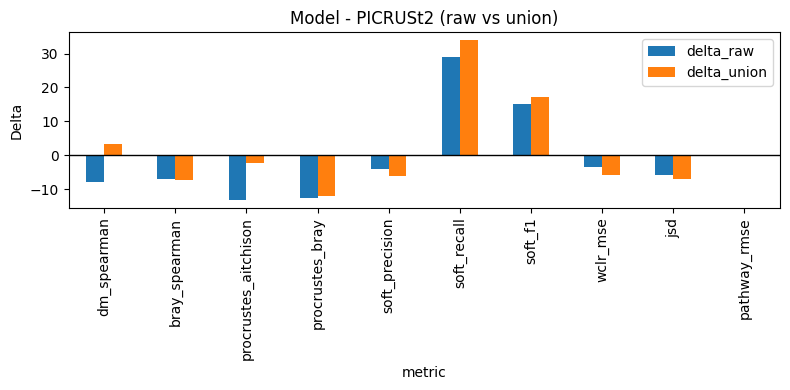

In [18]:
# Visualize deltas (positive = model better than PICRUSt2 for correlation metrics)
#multiply all except wclr_mse by 100 (all values in all rows except the row 'wclr_mse'):
compare_table_for_plotting = compare_table.copy()
compare_table_for_plotting.loc[compare_table_for_plotting['metric'] != 'wclr_mse', ['delta_raw', 'delta_union']] *= 100
        
if picrust_metrics is not None:
    plot_df = compare_table_for_plotting.set_index('metric')[['delta_raw', 'delta_union']]
    plot_df.plot(kind='bar', figsize=(8, 4))
    plt.axhline(0, color='black', linewidth=1)
    plt.title('Model - PICRUSt2 (raw vs union)')
    plt.ylabel('Delta')
    plt.tight_layout()
    plt.show()


## Procrustes overlays with ellipses
We overlay ordinations for truth vs prediction and truth vs PICRUSt2 (if available).


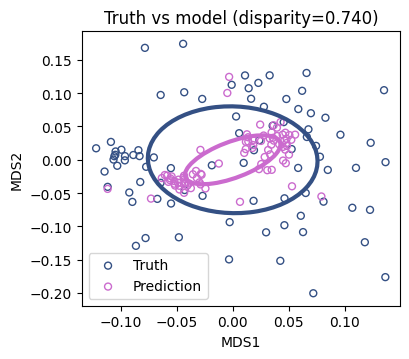

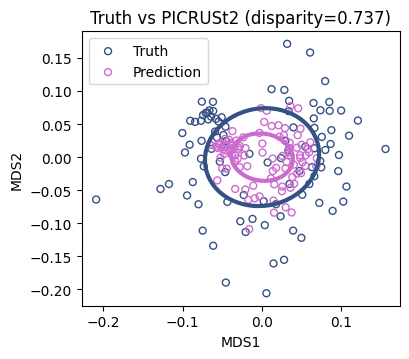

In [20]:
from matplotlib.patches import Ellipse
from scipy.spatial import procrustes
from sklearn.manifold import MDS
#import pdist, squareform
from scipy.spatial.distance import pdist, squareform

def _mds_coords_from_dm(D, random_state=42):
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=random_state)
    return mds.fit_transform(D)

def _plot_ellipse(ax, pts, color):
    cov = np.cov(pts[:, :2].T)
    mean = pts[:, :2].mean(axis=0)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * np.sqrt(vals)
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle, edgecolor=color, facecolor='none', lw=3)
    ax.add_patch(ellipse)

def clr_rows(df: pd.DataFrame, pseudocount: float = 0.5) -> pd.DataFrame:
    X = df.to_numpy(dtype=float)
    X = X + float(pseudocount)
    X = np.log(X)
    X = X - X.mean(axis=1, keepdims=True)
    return pd.DataFrame(X, index=df.index, columns=df.columns)

def aitchison_dm(Y_clr: pd.DataFrame) -> np.ndarray:
    # Euclidean in CLR space equals Aitchison distance
    return squareform(pdist(Y_clr.to_numpy(dtype=float), metric="euclidean"))

def plot_procrustes_overlay(truth_tss, pred_tss, title):
    # align by intersection of KOs
    common = truth_tss.columns.intersection(pred_tss.columns)
    t = truth_tss.loc[:, common]
    p = pred_tss.loc[:, common]
    t = t.div(t.sum(axis=1).replace(0, np.nan), axis=0)
    p = p.div(p.sum(axis=1).replace(0, np.nan), axis=0)

    t_clr = clr_rows(t, pseudocount=float(model_cfg['pseudocount_y']))
    p_clr = clr_rows(p, pseudocount=float(model_cfg['pseudocount_y']))
    good = t_clr.notna().all(axis=1) & p_clr.notna().all(axis=1)
    t_clr = t_clr.loc[good]
    p_clr = p_clr.loc[good]

    D_t = aitchison_dm(t_clr)
    D_p = aitchison_dm(p_clr)

    coords_t = _mds_coords_from_dm(D_t)
    coords_p = _mds_coords_from_dm(D_p)

    mt, mp, disparity = procrustes(coords_t, coords_p)

    fig, ax = plt.subplots(figsize=(4.2, 3.7))
    ax.scatter(mt[:, 0], mt[:, 1], s=25, facecolors='none', edgecolors='#345084', label='Truth')
    ax.scatter(mp[:, 0], mp[:, 1], s=25, facecolors='none', edgecolors='#CB6BCE', label='Prediction')
    _plot_ellipse(ax, mt, '#345084')
    _plot_ellipse(ax, mp, '#CB6BCE')
    ax.set_title(f'{title} (disparity={disparity:.3f})')
    ax.set_xlabel('MDS1')
    ax.set_ylabel('MDS2')
    ax.legend()
    plt.tight_layout()
    plt.show()

# Truth vs model
plot_procrustes_overlay(Y, oof_fixed_tss, title='Truth vs model')

# Truth vs PICRUSt2 (if available)
if 'picrust' in locals() and picrust is not None:
    plot_procrustes_overlay(Y, picrust, title='Truth vs PICRUSt2')


## Pathway deviation plots (log10)
We compare pathway-level deviations vs. truth for model and PICRUSt2 (raw vs union).


In [27]:
truth_pw

,Amino acid metabolism,Antibiotic resistance/efflux,Carbohydrate metabolism,Cell envelope/biogenesis,Cofactors/vitamins,DNA replication/repair/maintenance,Defense systems,Drug metabolism/xenobiotics,Energy/central carbon,Lipid metabolism,...,RNA processing/degradation,SCFA fermentation,Secondary metabolism,Signal transduction,Synaptic pathways,Transcriptional regulation,Translation/ribosome,Transport,Tryptophan metabolism,Viral processes
0180e,0.032720,0.014838,0.153979,0.041103,0.021012,0.066513,0.016260,1.064642e-07,0.084596,0.017918,...,0.064009,0.016966,0.001830,0.016503,0.000046,0.023055,0.132819,0.174701,0.015652,0.002551
05cc8,0.032656,0.014864,0.155547,0.041677,0.021200,0.065577,0.015465,9.596251e-08,0.085454,0.016490,...,0.062359,0.016565,0.001596,0.016714,0.000134,0.024228,0.134863,0.175809,0.015367,0.002676
1dbe4,0.044480,0.020470,0.169057,0.031015,0.032829,0.059486,0.008380,3.959930e-09,0.117903,0.015747,...,0.045718,0.009223,0.000946,0.017466,0.003024,0.026186,0.109605,0.165460,0.015214,0.002736
27fc0,0.032442,0.014623,0.152295,0.042135,0.020861,0.066281,0.015878,6.795553e-08,0.084927,0.017421,...,0.063704,0.016946,0.001786,0.016253,0.000040,0.023178,0.135235,0.175689,0.015778,0.002623
3143d,0.038663,0.015869,0.195112,0.032617,0.021473,0.060140,0.012142,1.882513e-08,0.093080,0.012749,...,0.053325,0.015065,0.000728,0.020609,0.000494,0.030712,0.105264,0.174835,0.014186,0.002785
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
vubh094,0.037435,0.019540,0.185423,0.028172,0.022972,0.058469,0.015707,7.398671e-08,0.098484,0.007841,...,0.047413,0.010191,0.000052,0.020422,0.000975,0.040413,0.082380,0.205814,0.017881,0.002762
vubh095,0.037648,0.013698,0.217283,0.024425,0.022085,0.045623,0.012465,1.142193e-07,0.102119,0.011802,...,0.044445,0.014199,0.001123,0.021468,0.000601,0.040168,0.080388,0.194025,0.016568,0.003822
vubh097,0.032655,0.014623,0.154975,0.041814,0.020828,0.065405,0.015432,3.100257e-07,0.085653,0.016923,...,0.061994,0.016866,0.001712,0.016371,0.000134,0.023665,0.133866,0.177016,0.015888,0.002826
vubh105,0.036144,0.017096,0.186401,0.034084,0.021936,0.061730,0.013054,5.172081e-07,0.087640,0.012724,...,0.055686,0.013318,0.000670,0.020084,0.000582,0.031694,0.105843,0.181329,0.015356,0.003397


In [28]:
model_pw

,Amino acid metabolism,Antibiotic resistance/efflux,Carbohydrate metabolism,Cell envelope/biogenesis,Cofactors/vitamins,DNA replication/repair/maintenance,Defense systems,Drug metabolism/xenobiotics,Energy/central carbon,Lipid metabolism,...,RNA processing/degradation,SCFA fermentation,Secondary metabolism,Signal transduction,Synaptic pathways,Transcriptional regulation,Translation/ribosome,Transport,Tryptophan metabolism,Viral processes
0180e,0.031900,0.012911,0.159295,0.039089,0.021059,0.069985,0.013632,0.000002,0.084616,0.015101,...,0.062763,0.014623,0.001195,0.017386,0.000255,0.026751,0.132624,0.180313,0.014782,0.003038
05cc8,0.032052,0.013008,0.160365,0.038897,0.021215,0.070046,0.013498,0.000002,0.084674,0.014992,...,0.062325,0.014488,0.001151,0.017543,0.000288,0.026968,0.131398,0.180974,0.014631,0.003088
1dbe4,0.033395,0.013510,0.167705,0.037617,0.021603,0.069053,0.012603,0.000002,0.085357,0.014318,...,0.060934,0.014062,0.000963,0.018362,0.000479,0.028698,0.123598,0.182198,0.014575,0.003210
27fc0,0.031926,0.012933,0.159882,0.038963,0.021161,0.070142,0.013604,0.000002,0.084669,0.015051,...,0.062819,0.014599,0.001181,0.017531,0.000272,0.026717,0.132226,0.179945,0.014672,0.003051
3143d,0.034140,0.013282,0.172822,0.036535,0.021691,0.068249,0.012327,0.000002,0.086121,0.014203,...,0.059187,0.013786,0.000902,0.018741,0.000643,0.030102,0.118928,0.183660,0.014692,0.003235
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
vubh094,0.034502,0.013069,0.173338,0.036898,0.021261,0.068844,0.011879,0.000002,0.085703,0.014277,...,0.059520,0.013654,0.000879,0.018748,0.000772,0.030141,0.118331,0.182886,0.014639,0.003336
vubh095,0.034050,0.013159,0.170972,0.036977,0.021819,0.069034,0.011736,0.000002,0.086651,0.014576,...,0.059586,0.013540,0.000998,0.018828,0.000675,0.029913,0.119337,0.183535,0.014846,0.003328
vubh097,0.031819,0.012861,0.160393,0.038896,0.021234,0.069978,0.013404,0.000002,0.084640,0.015100,...,0.062575,0.014558,0.001190,0.017512,0.000287,0.027045,0.131389,0.180998,0.014702,0.003057
vubh105,0.033681,0.013228,0.169753,0.037144,0.021605,0.068930,0.012451,0.000002,0.085783,0.014280,...,0.060223,0.013939,0.000948,0.018515,0.000552,0.029315,0.122138,0.182901,0.014586,0.003222


In [30]:
pic_pw = None
if 'picrust' in locals() and picrust is not None:
    pic_pw = _aggregate_to_pathway(picrust, ko_to_superclass)

pic_pw    

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/1055170541.py:8: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  return out.groupby(level=0, axis=1).sum()


,Amino acid metabolism,Antibiotic resistance/efflux,Carbohydrate metabolism,Cell envelope/biogenesis,Cofactors/vitamins,DNA replication/repair/maintenance,Defense systems,Drug metabolism/xenobiotics,Energy/central carbon,Lipid metabolism,...,RNA processing/degradation,SCFA fermentation,Secondary metabolism,Signal transduction,Synaptic pathways,Transcriptional regulation,Translation/ribosome,Transport,Tryptophan metabolism,Viral processes
0180e,38404.65,10798.57,162203.14,33571.93,23993.10,83961.79,9604.57,0.0,97245.97,22781.21,...,68368.39,14389.70,0.00,27619.31,1198.17,18065.48,157097.57,135698.95,13207.61,2404.34
05cc8,38443.00,10811.00,162335.00,33604.00,24016.00,84040.00,9610.00,0.0,97342.00,22800.00,...,68419.00,14395.00,0.00,27658.00,1203.00,18088.00,157188.00,135898.00,13226.00,2406.00
1dbe4,42711.00,13050.00,177258.00,34203.00,27239.00,86608.00,10823.00,0.0,110626.00,22906.00,...,69259.00,13873.00,0.00,29830.00,1790.00,22180.00,157651.00,152095.00,14688.00,2757.00
27fc0,38553.00,10832.00,162515.00,33611.00,24071.00,84066.00,9641.00,0.0,97626.00,22802.00,...,68457.00,14413.00,1.00,27654.00,1208.00,18118.00,157222.00,136223.00,13285.00,2415.00
3143d,44423.20,13152.76,235980.44,31451.22,27561.94,84024.44,11742.10,2.0,119488.72,19621.84,...,68579.88,14372.52,0.00,39271.24,909.00,33994.20,148407.70,184716.46,17586.18,3422.94
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
vubh094,50753.05,20266.89,252784.89,33551.58,26571.57,98760.54,22552.06,0.0,137103.33,12109.23,...,75044.84,8379.58,0.33,43463.69,1243.27,47724.10,138469.40,256412.28,30174.64,2480.66
vubh095,63153.18,22285.12,259917.38,38265.01,40407.90,101768.78,14949.29,0.0,176270.50,25007.99,...,73410.37,11330.86,0.00,42695.47,5446.24,46868.94,154353.26,249832.87,23477.25,4777.35
vubh097,38591.86,10914.11,163035.73,33586.40,24180.70,83971.47,9638.90,2.0,97891.72,22793.77,...,68336.56,14368.02,0.00,27767.53,1214.01,18292.34,156948.55,136567.73,13347.19,2425.16
vubh105,43829.00,13159.00,206393.00,33991.00,27044.00,87976.00,11933.00,0.0,114348.00,21565.00,...,71759.00,14550.00,4.00,34687.00,1131.00,28026.00,157238.00,172622.00,17080.00,2954.00


/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/3012653753.py:8: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  return out.groupby(level=0, axis=1).sum()
/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/3012653753.py:8: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  return out.groupby(level=0, axis=1).sum()
/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/3012653753.py:8: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  return out.groupby(level=0, axis=1).sum()


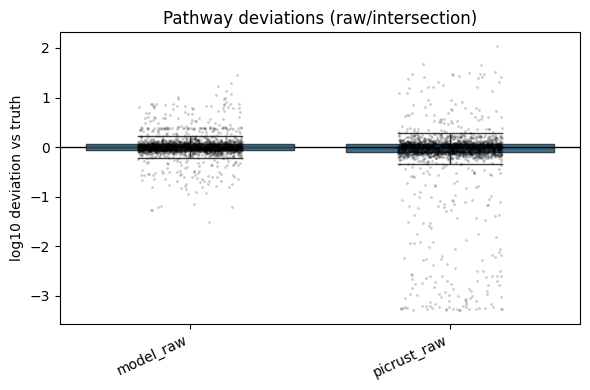

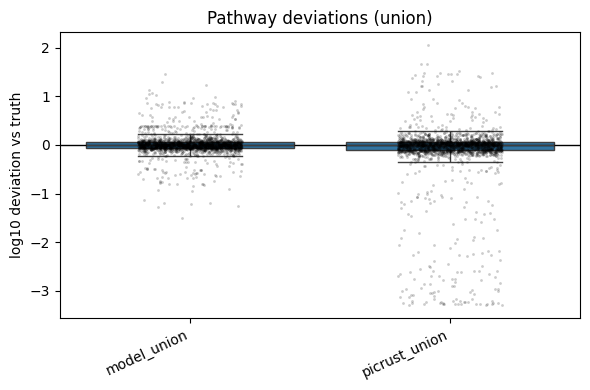

In [31]:
def _aggregate_to_pathway(tss, ko_to_group):
    common = [c for c in tss.columns if c in ko_to_group]
    if not common:
        return pd.DataFrame(index=tss.index)
    groups = [ko_to_group[c] for c in common]
    out = tss.loc[:, common].copy()
    out.columns = groups
    return out.groupby(level=0, axis=1).sum()

def _align_union(a, b):
    cols = a.columns.union(b.columns)
    return a.reindex(columns=cols, fill_value=0.0), b.reindex(columns=cols, fill_value=0.0)

def _align_intersection(a, b):
    cols = a.columns.intersection(b.columns)
    return a.loc[:, cols], b.loc[:, cols]

def build_deviation_long(tables_aligned, ref_name='truth', eps=1e-6):
    ref = tables_aligned[ref_name]
    rows = []
    for cfg, df in tables_aligned.items():
        if cfg == ref_name:
            continue
        common = df.index.intersection(ref.index)
        A = df.loc[common]
        R = ref.loc[common]
        dev = np.log10(A + eps) - np.log10(R + eps)
        long = dev.stack().reset_index()
        long.columns = ['sample', 'pathway', 'deviation_log10']
        long['cfg'] = cfg
        rows.append(long)
    return pd.concat(rows, ignore_index=True)

# Aggregate to pathways
truth_pw = _aggregate_to_pathway(Y.div(Y.sum(axis=1).replace(0, np.nan), axis=0), ko_to_superclass)
model_pw = _aggregate_to_pathway(oof_fixed_tss, ko_to_superclass)

pic_pw = None
if 'picrust' in locals() and picrust is not None:
    pic_pw = _aggregate_to_pathway(picrust, ko_to_superclass)
    #make relative abundance of pic_pw:
    pic_pw = pic_pw.div(pic_pw.sum(axis=1).replace(0, np.nan), axis=0)

# Build raw (intersection) and union-aligned tables
tables_raw = {'truth': truth_pw}
t_m, m_m = _align_intersection(truth_pw, model_pw)
tables_raw['model_raw'] = m_m
if pic_pw is not None:
    t_p, p_p = _align_intersection(truth_pw, pic_pw)
    tables_raw['picrust_raw'] = p_p

tables_union = {'truth': truth_pw}
t_u, m_u = _align_union(truth_pw, model_pw)
tables_union['model_union'] = m_u
if pic_pw is not None:
    t_u2, p_u2 = _align_union(truth_pw, pic_pw)
    tables_union['picrust_union'] = p_u2

dev_raw = build_deviation_long(tables_raw, ref_name='truth', eps=1e-6)
dev_union = build_deviation_long(tables_union, ref_name='truth', eps=1e-6)

# Plot distributions (box + strip)
import seaborn as sns

def _plot_dev(dev_long, title):
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=dev_long, x='cfg', y='deviation_log10', showfliers=False)
    sns.stripplot(data=dev_long, x='cfg', y='deviation_log10', color='black', alpha=0.2, jitter=0.2, size=2)
    plt.axhline(0, color='black', lw=1)
    plt.title(title)
    plt.xlabel('')
    plt.ylabel('log10 deviation vs truth')
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    plt.show()

_plot_dev(dev_raw, 'Pathway deviations (raw/intersection)')
_plot_dev(dev_union, 'Pathway deviations (union)')


## Pathway statistics (Wilcoxon + CLD)
We run paired Wilcoxon tests on per-sample pathway deviations and visualize CLD letters.


In [32]:
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon
import seaborn as sns
import matplotlib.pyplot as plt

def bh_fdr(pvals: np.ndarray) -> np.ndarray:
    p = np.asarray(pvals, float)
    out = np.full_like(p, np.nan)
    ok = np.isfinite(p)
    if ok.sum() == 0:
        return out
    pv = p[ok]
    order = np.argsort(pv)
    ranked = pv[order]
    m = len(ranked)
    q = ranked * m / (np.arange(1, m + 1))
    q = np.minimum.accumulate(q[::-1])[::-1]
    tmp = np.empty_like(pv)
    tmp[order] = np.clip(q, 0, 1)
    out[ok] = tmp
    return out

def pairwise_paired_wilcoxon_for_pathway(dev_long: pd.DataFrame, pathway: str, cfg_order=None,
                                         min_pairs=10, zero_method='wilcox',
                                         alternative='two-sided') -> pd.DataFrame:
    d = dev_long[dev_long['pathway'] == pathway].copy()
    if d.empty:
        return pd.DataFrame(columns=['pathway','cfg1','cfg2','p','p_adj','n_pairs'])
    if cfg_order is None:
        cfgs = sorted(d['cfg'].unique())
    else:
        cfgs = [c for c in cfg_order if c in d['cfg'].unique()]
    by = {cfg: d[d['cfg'] == cfg].set_index('sample')['deviation_log10'] for cfg in cfgs}
    rows = []
    for i in range(len(cfgs)):
        for j in range(i + 1, len(cfgs)):
            a, b = cfgs[i], cfgs[j]
            sa, sb = by[a], by[b]
            common = sa.index.intersection(sb.index)
            if len(common) < min_pairs:
                rows.append({'pathway': pathway, 'cfg1': a, 'cfg2': b, 'p': np.nan, 'n_pairs': len(common)})
                continue
            diff = (sa.loc[common] - sb.loc[common]).to_numpy(dtype=float)
            diff = diff[np.isfinite(diff)]
            if diff.size < min_pairs:
                rows.append({'pathway': pathway, 'cfg1': a, 'cfg2': b, 'p': np.nan, 'n_pairs': int(diff.size)})
                continue
            if np.allclose(diff, 0):
                p = 1.0
            else:
                p = float(wilcoxon(diff, zero_method=zero_method, alternative=alternative).pvalue)
            rows.append({'pathway': pathway, 'cfg1': a, 'cfg2': b, 'p': p, 'n_pairs': int(diff.size)})
    out = pd.DataFrame(rows)
    out['p_adj'] = bh_fdr(out['p'].to_numpy())
    return out

def wilcoxon_vs_zero_for_pathway(dev_long: pd.DataFrame, pathway: str, cfg_order=None,
                                 min_n=10, zero_method='wilcox',
                                 alternative='two-sided') -> pd.DataFrame:
    d = dev_long[dev_long['pathway'] == pathway].copy()
    if d.empty:
        return pd.DataFrame(columns=['pathway','cfg','p','p_adj','n','median'])
    if cfg_order is None:
        cfgs = sorted(d['cfg'].unique())
    else:
        cfgs = [c for c in cfg_order if c in d['cfg'].unique()]
    rows = []
    for cfg in cfgs:
        x = d.loc[d['cfg'] == cfg, 'deviation_log10'].to_numpy(dtype=float)
        x = x[np.isfinite(x)]
        n = int(x.size)
        if n < min_n:
            rows.append({'pathway': pathway, 'cfg': cfg, 'p': np.nan, 'n': n, 'median': np.nan})
            continue
        med = float(np.median(x))
        if np.allclose(x, 0):
            p = 1.0
        else:
            p = float(wilcoxon(x, zero_method=zero_method, alternative=alternative).pvalue)
        rows.append({'pathway': pathway, 'cfg': cfg, 'p': p, 'n': n, 'median': med})
    out = pd.DataFrame(rows)
    out['p_adj'] = bh_fdr(out['p'].to_numpy())
    return out

def compute_cld_letters(cfgs, pairwise_df, p_col='p_adj', alpha=0.05, value_by_cfg=None):
    p_lookup = {}
    for _, r in pairwise_df.iterrows():
        a, b = r['cfg1'], r['cfg2']
        p_lookup[tuple(sorted((a, b)))] = r[p_col]
    def nonsig(a, b):
        if a == b:
            return True
        p = p_lookup.get(tuple(sorted((a, b))), np.nan)
        if not np.isfinite(p):
            return False
        return p >= alpha
    if value_by_cfg is not None:
        order = list(value_by_cfg.loc[cfgs].sort_values(ascending=False).index)
    else:
        order = list(cfgs)
    letter_groups = []
    for cfg in order:
        placed = False
        for grp in letter_groups:
            if all(nonsig(cfg, other) for other in grp):
                grp.append(cfg)
                placed = True
                break
        if not placed:
            letter_groups.append([cfg])
    def idx_to_letters(i):
        s = ''
        i0 = i
        while True:
            s = chr(ord('a') + (i0 % 26)) + s
            i0 = i0 // 26 - 1
            if i0 < 0:
                break
        return s
    cld = {cfg: '' for cfg in cfgs}
    for gi, grp in enumerate(letter_groups):
        L = idx_to_letters(gi)
        for cfg in grp:
            cld[cfg] += L
    return cld

def plot_pathway_pairwise_cld(
    dev_long: pd.DataFrame,
    pathway: str,
    pairwise_df: pd.DataFrame,
    cfg_order=None,
    kind='box',
    palette=None,
    figsize=(6, 4),
    sig_cutoff=0.05,
    p_col='p_adj',
    cld_order_by='median',
    y_max_cap=None,
    savepath=None,
):
    d = dev_long[dev_long['pathway'] == pathway].copy()
    if d.empty:
        raise ValueError(f"No data for pathway '{pathway}'.")
    if cfg_order is None:
        cfgs = sorted(d['cfg'].unique())
    else:
        cfgs = [c for c in cfg_order if c in d['cfg'].unique()]
    if y_max_cap is not None:
        d = d[np.abs(d['deviation_log10']) <= y_max_cap]
    if palette is None:
        palette = sns.color_palette(n_colors=len(cfgs))
    fig, ax = plt.subplots(figsize=figsize)
    if kind == 'violin':
        sns.violinplot(data=d, x='cfg', y='deviation_log10',
            order=cfgs, palette=palette, inner=None, cut=0, linewidth=1, ax=ax)
    else:
        sns.boxplot(data=d, x='cfg', y='deviation_log10',
            order=cfgs, palette=palette, showfliers=False, linewidth=2, ax=ax,
            boxprops=dict(alpha=0.5))
    sns.stripplot(data=d, x='cfg', y='deviation_log10',
        order=cfgs, color='#751C6DFF', alpha=0.35, jitter=0.25, size=2.5, ax=ax)
    ax.axhline(0, lw=1, color='black')
    ax.set_title(f"{pathway} — pairwise Wilcoxon", fontsize=16, loc='left')
    ax.set_xlabel('')
    ax.set_ylabel('log10 deviation vs shotgun', fontsize=14)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    plt.xticks(rotation=45, ha='right')
    sns.despine(ax=ax, top=True, right=True)
    if cld_order_by == 'median':
        stat = d.groupby('cfg')['deviation_log10'].median()
    elif cld_order_by == 'mean':
        stat = d.groupby('cfg')['deviation_log10'].mean()
    else:
        stat = None
    cld = compute_cld_letters(cfgs, pairwise_df, p_col=p_col, alpha=sig_cutoff, value_by_cfg=stat)
    group_max = d.groupby('cfg')['deviation_log10'].max()
    y_range = (d['deviation_log10'].max() - d['deviation_log10'].min()) if len(d) else 1.0
    offset = max(0.05, 0.05 * y_range)
    for xi, cfg in enumerate(cfgs):
        if cfg not in group_max or pd.isna(group_max[cfg]):
            continue
        ax.text(xi, float(group_max[cfg]) + offset, cld.get(cfg, ''),
            ha='center', va='bottom', fontsize=14, color='black')
    cur_ymin, cur_ymax = ax.get_ylim()
    ax.set_ylim(cur_ymin, max(cur_ymax, float(group_max.max()) + 2 * offset))
    if y_max_cap is not None:
        ax.set_ylim(-y_max_cap, y_max_cap)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()
    return fig

def p_to_stars(p):
    if not np.isfinite(p):
        return ''
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'

def plot_pathway_vs_zero(
    dev_long: pd.DataFrame,
    pathway: str,
    vs0_df: pd.DataFrame,
    cfg_order=None,
    kind='box',
    palette=None,
    figsize=(6, 4),
    sig_cutoff=0.05,
    p_col='p_adj',
    label_style='stars',
    y_max_cap=None,
    savepath=None,
):
    d = dev_long[dev_long['pathway'] == pathway].copy()
    if d.empty:
        raise ValueError(f"No data for pathway '{pathway}'.")
    if cfg_order is None:
        cfgs = sorted(d['cfg'].unique())
    else:
        cfgs = [c for c in cfg_order if c in d['cfg'].unique()]
    if y_max_cap is not None:
        d = d[np.abs(d['deviation_log10']) <= y_max_cap]
    if palette is None:
        palette = sns.color_palette(n_colors=len(cfgs))
    fig, ax = plt.subplots(figsize=figsize)
    if kind == 'violin':
        sns.violinplot(data=d, x='cfg', y='deviation_log10',
            order=cfgs, palette=palette, inner=None, cut=0, linewidth=1, ax=ax)
    else:
        sns.boxplot(data=d, x='cfg', y='deviation_log10',
            order=cfgs, palette=palette, showfliers=False, linewidth=2, ax=ax,
            boxprops=dict(alpha=0.5))
    sns.stripplot(data=d, x='cfg', y='deviation_log10',
        order=cfgs, color='#751C6DFF', alpha=0.35, jitter=0.25, size=2.5, ax=ax)
    ax.axhline(0, lw=1, color='black')
    ax.set_title(f"{pathway} — Wilcoxon vs 0", fontsize=16, loc='left')
    ax.set_xlabel('')
    ax.set_ylabel('log10 deviation vs shotgun', fontsize=14)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    plt.xticks(rotation=45, ha='right')
    sns.despine(ax=ax, top=True, right=True)
    group_max = d.groupby('cfg')['deviation_log10'].max()
    y_range = (d['deviation_log10'].max() - d['deviation_log10'].min()) if len(d) else 1.0
    offset = max(0.05, 0.05 * y_range)
    vs0_df = vs0_df.set_index('cfg')
    for xi, cfg in enumerate(cfgs):
        if cfg not in group_max or pd.isna(group_max[cfg]):
            continue
        q = float(vs0_df.loc[cfg, p_col]) if cfg in vs0_df.index else np.nan
        if label_style == 'q':
            lab = f"q={q:.3g}" if np.isfinite(q) else ''
        else:
            lab = p_to_stars(q)
        ax.text(xi, float(group_max[cfg]) + offset, lab,
            ha='center', va='bottom', fontsize=12, color='black')
    cur_ymin, cur_ymax = ax.get_ylim()
    ax.set_ylim(cur_ymin, max(cur_ymax, float(group_max.max()) + 2 * offset))
    if y_max_cap is not None:
        ax.set_ylim(-y_max_cap, y_max_cap)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()
    return fig

def plot_two_per_pathway(
    dev_long: pd.DataFrame,
    pathway: str,
    cfg_order=None,
    kind='box',
    palette=None,
    min_pairs=10,
    min_n=10,
    sig_cutoff=0.05,
    y_max_cap=None,
    outdir='results/pathway_stats',
):
    import os
    os.makedirs(outdir, exist_ok=True)
    pairwise_df = pairwise_paired_wilcoxon_for_pathway(
        dev_long, pathway, cfg_order=cfg_order, min_pairs=min_pairs
    )
    vs0_df = wilcoxon_vs_zero_for_pathway(
        dev_long, pathway, cfg_order=cfg_order, min_n=min_n
    )
    safe = pathway.replace('/', '_').replace(' ', '_')
    plot_pathway_pairwise_cld(
        dev_long, pathway, pairwise_df,
        cfg_order=cfg_order, kind=kind, palette=palette,
        sig_cutoff=sig_cutoff, y_max_cap=y_max_cap,
        savepath=f"{outdir}/{safe}__pairwise_cld.pdf"
    )
    plot_pathway_vs_zero(
        dev_long, pathway, vs0_df,
        cfg_order=cfg_order, kind=kind, palette=palette,
        sig_cutoff=sig_cutoff, y_max_cap=y_max_cap,
        label_style='stars',
        savepath=f"{outdir}/{safe}__vs0.pdf"
    )
    return pairwise_df, vs0_df


In [35]:
dev_union

,sample,pathway,deviation_log10,cfg
0,0180e,Amino acid metabolism,-0.011030,model_union
1,0180e,Antibiotic resistance/efflux,-0.060429,model_union
2,0180e,Carbohydrate metabolism,0.014739,model_union
3,0180e,Cell envelope/biogenesis,-0.021814,model_union
4,0180e,Cofactors/vitamins,0.000965,model_union
...,...,...,...,...
4745,vubh107,Transcriptional regulation,-0.039372,picrust_union
4746,vubh107,Translation/ribosome,0.047886,picrust_union
4747,vubh107,Transport,-0.033888,picrust_union
4748,vubh107,Tryptophan metabolism,0.000646,picrust_union


Processing pathway: Amino acid metabolism


/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


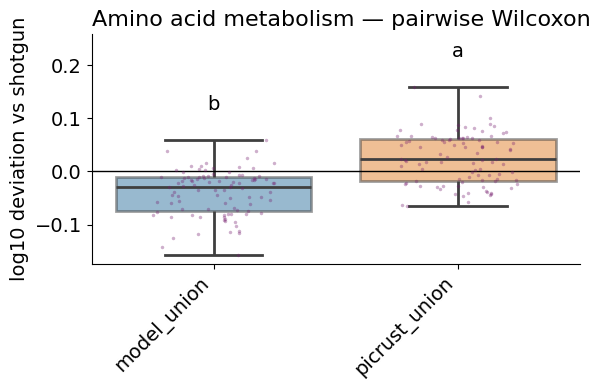

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:237: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


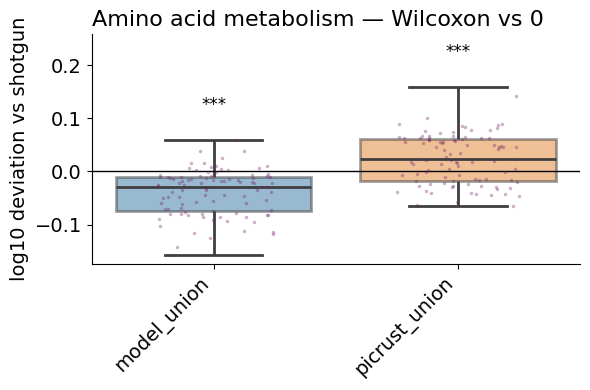

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


Processing pathway: Antibiotic resistance/efflux


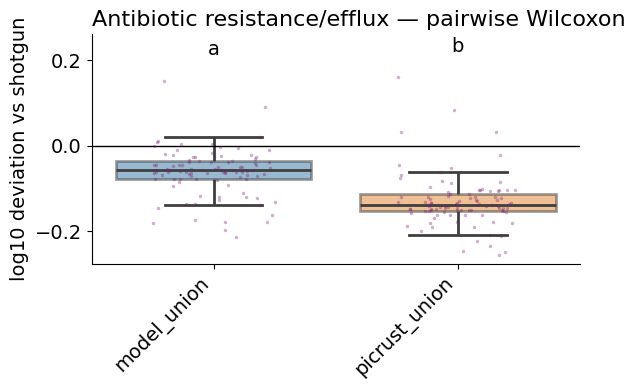

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:237: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


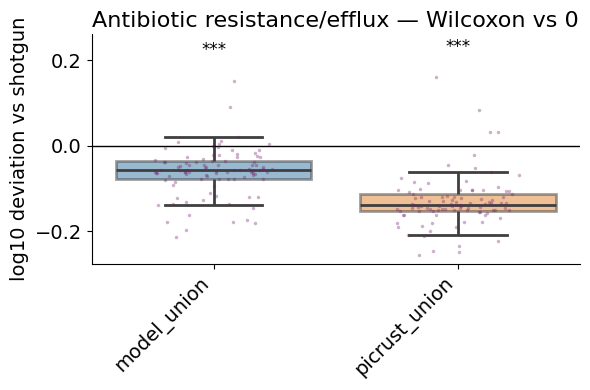

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


Processing pathway: Carbohydrate metabolism


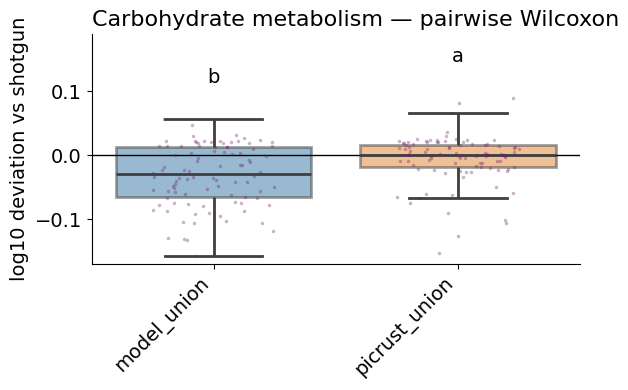

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:237: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


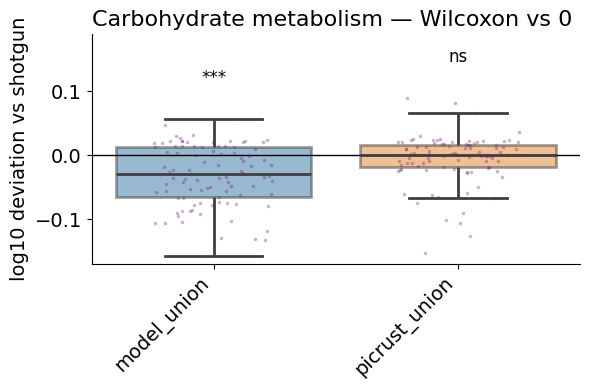

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


Processing pathway: Cell envelope/biogenesis


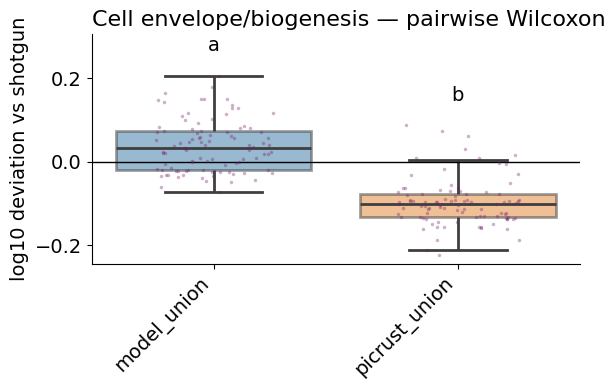

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:237: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


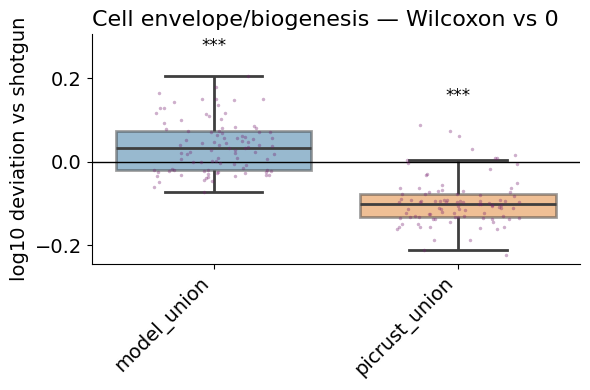

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


Processing pathway: Cofactors/vitamins


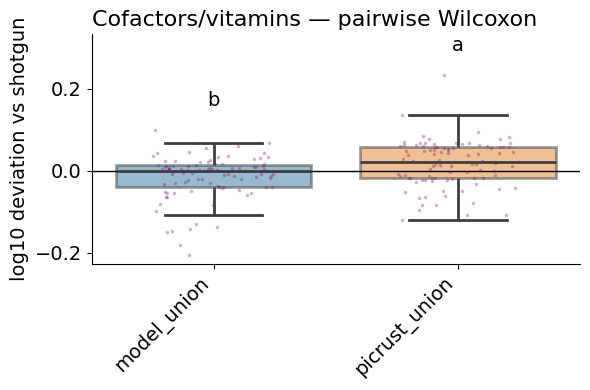

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:237: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


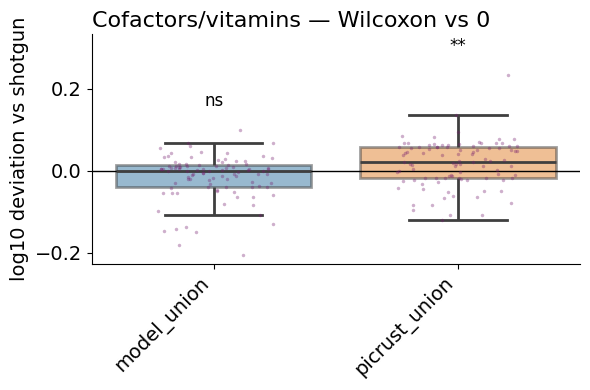

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


Processing pathway: DNA replication/repair/maintenance


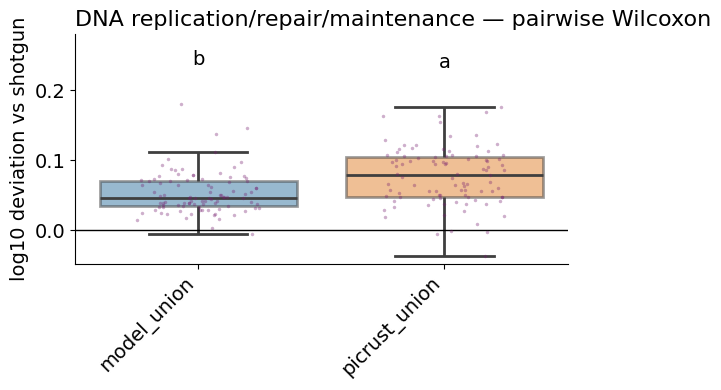

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:237: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


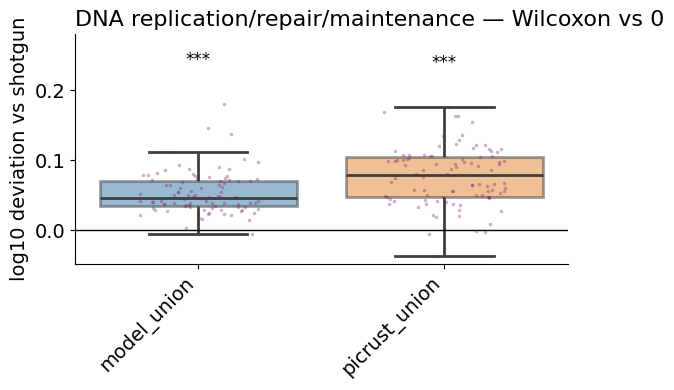

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


Processing pathway: Defense systems


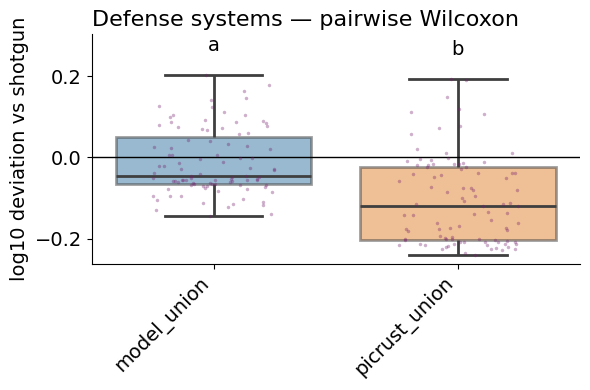

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:237: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


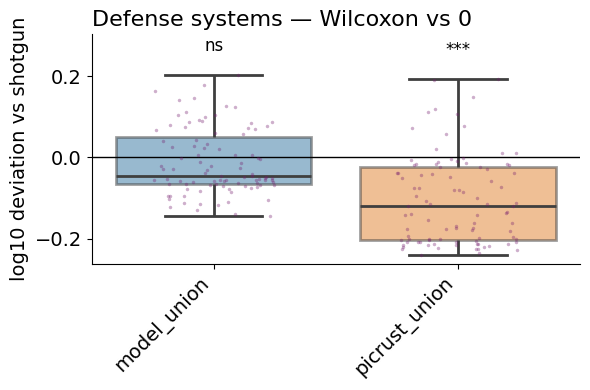

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


Processing pathway: Drug metabolism/xenobiotics


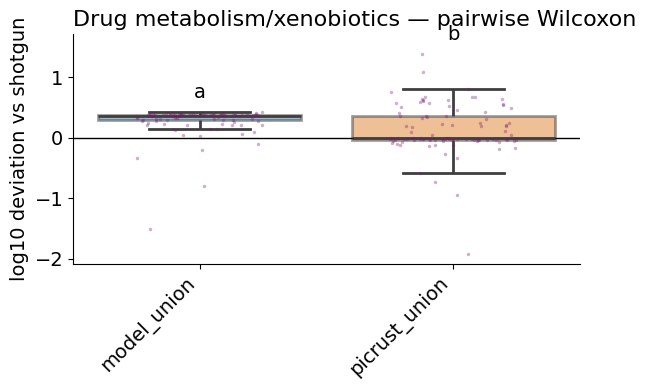

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:237: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


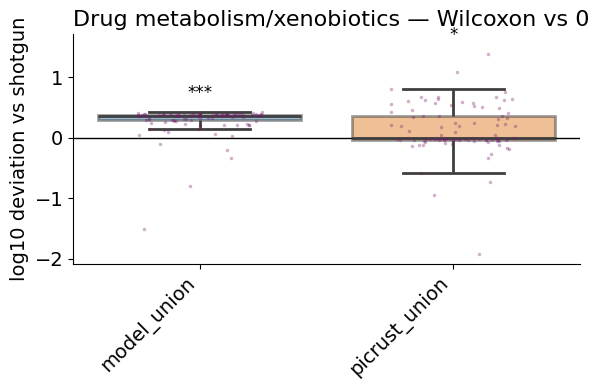

Processing pathway: Energy/central carbon


/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


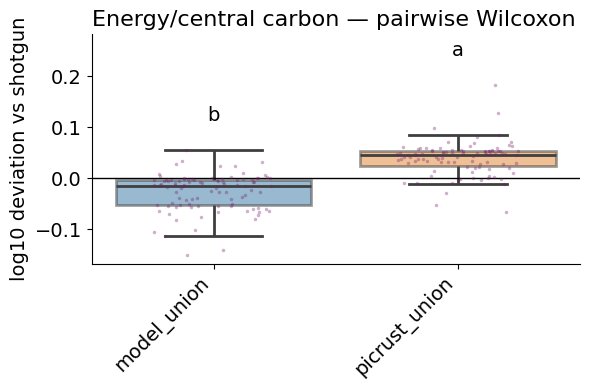

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:237: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


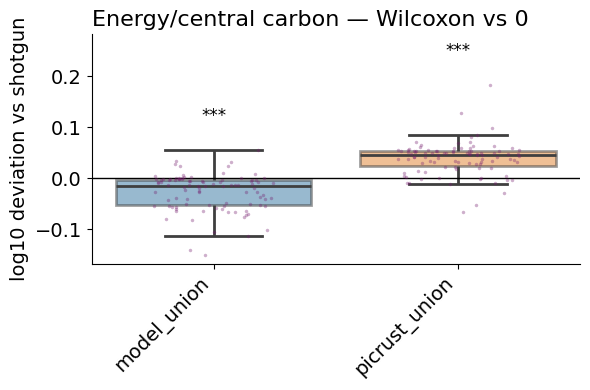

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


Processing pathway: Lipid metabolism


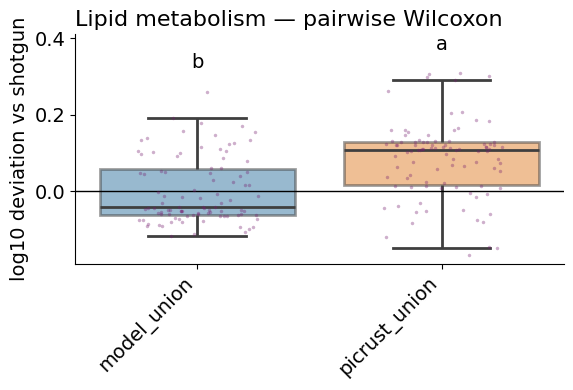

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:237: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


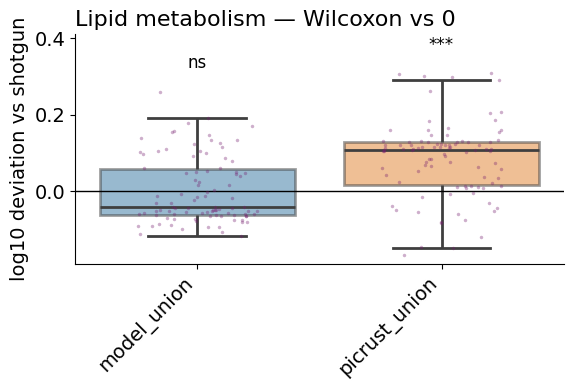

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


Processing pathway: Mobilome


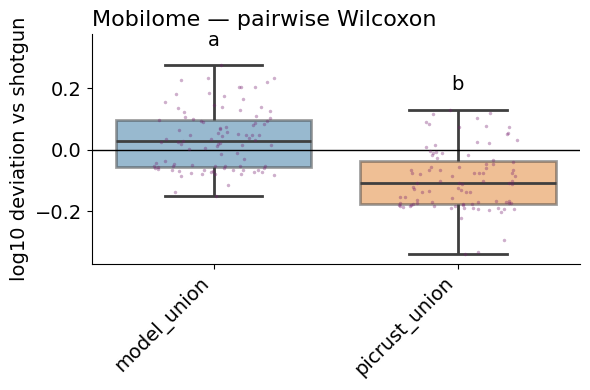

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:237: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


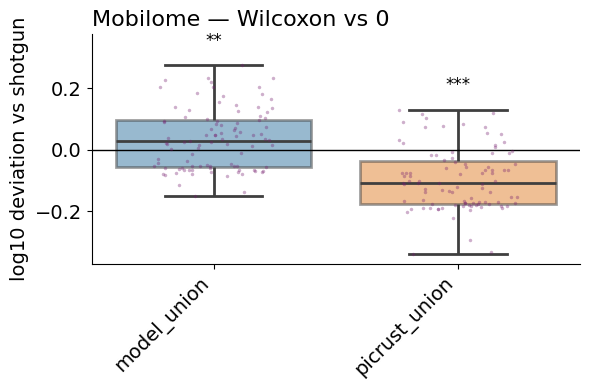

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


Processing pathway: Motility/adhesion


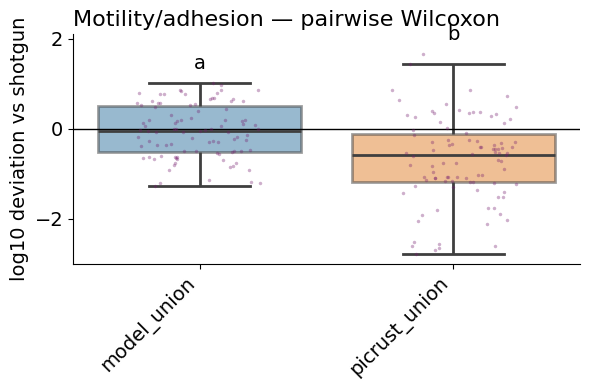

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:237: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


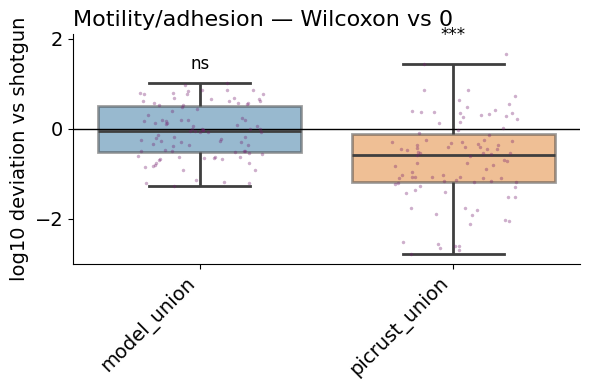

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


Processing pathway: Nucleotide metabolism


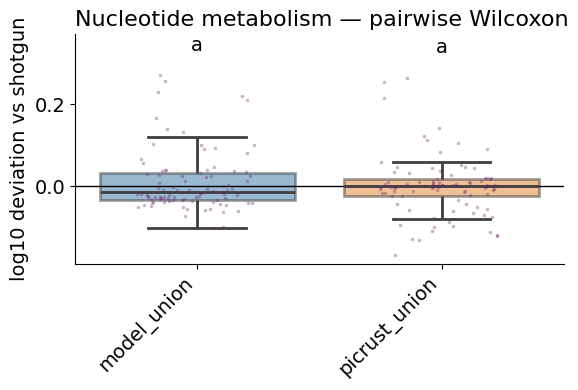

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:237: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


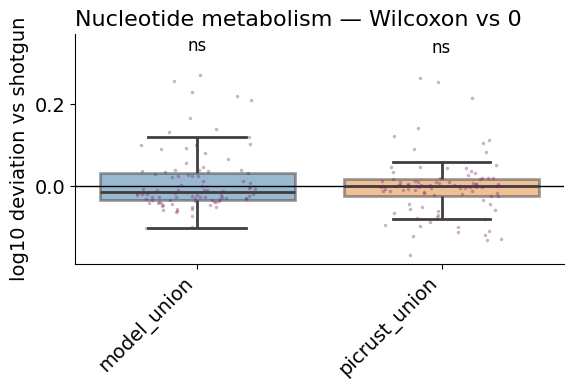

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


Processing pathway: Other


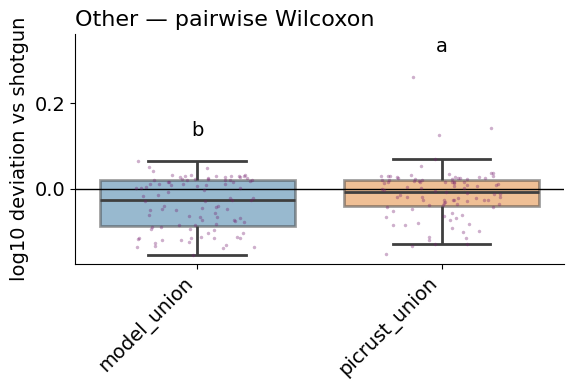

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:237: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


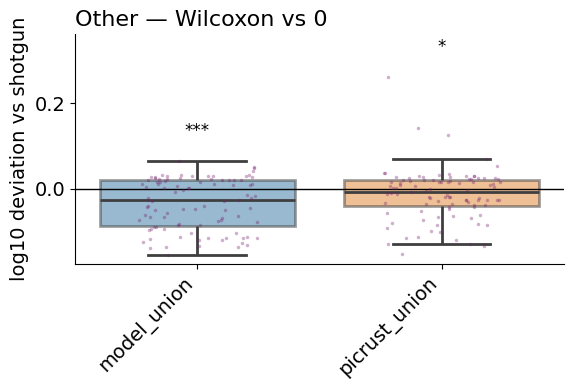

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


Processing pathway: Protein folding/quality control


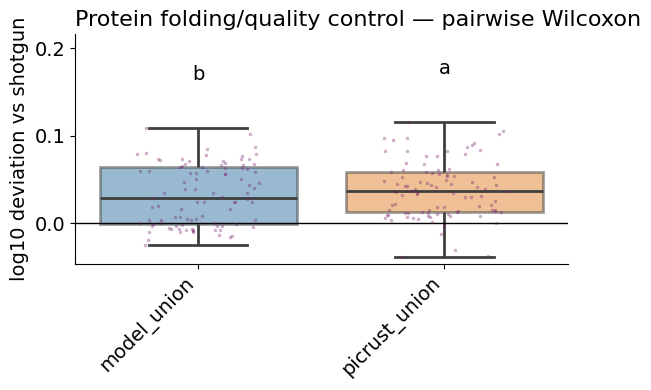

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:237: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


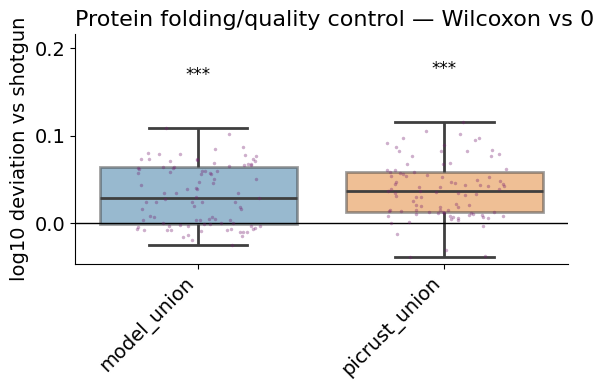

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


Processing pathway: RNA processing/degradation


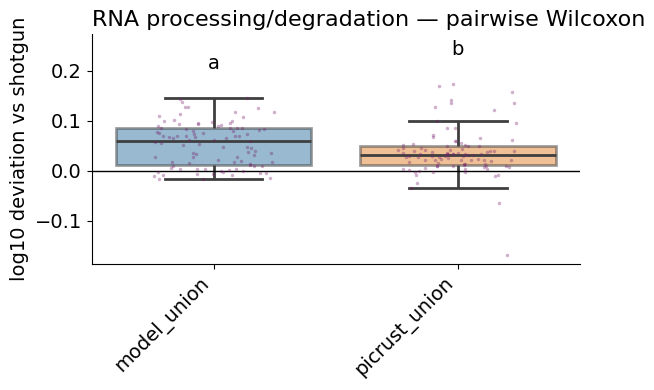

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:237: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


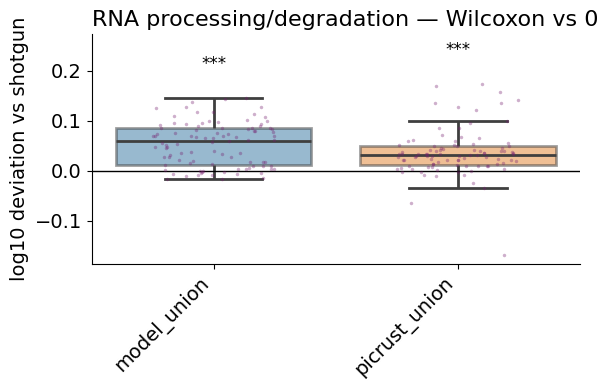

Processing pathway: SCFA fermentation


/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


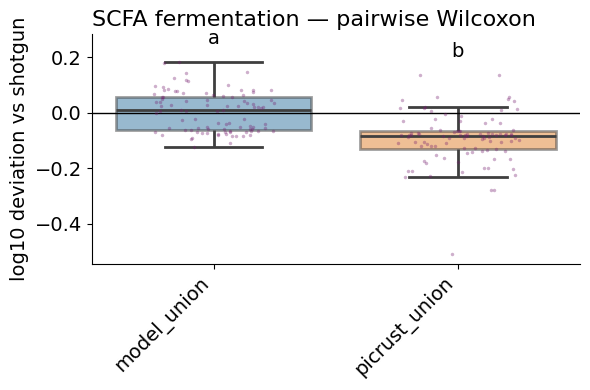

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:237: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


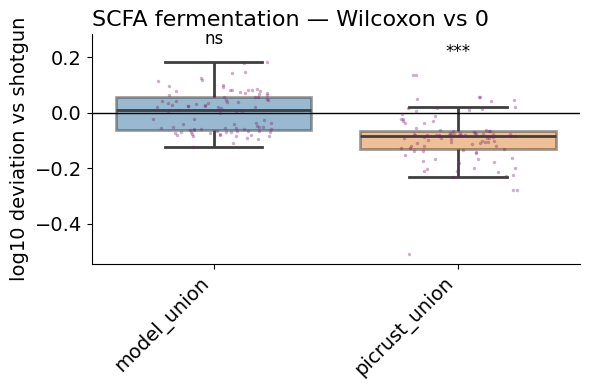

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


Processing pathway: Secondary metabolism


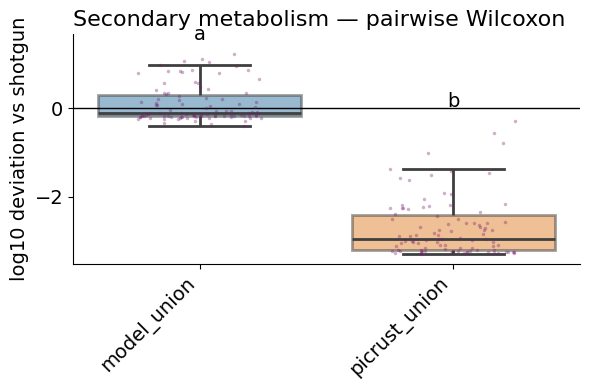

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:237: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


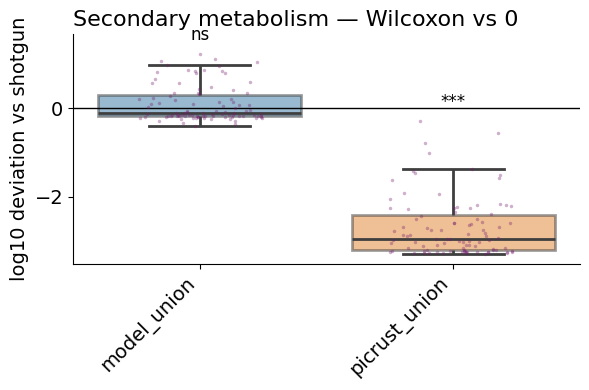

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


Processing pathway: Signal transduction


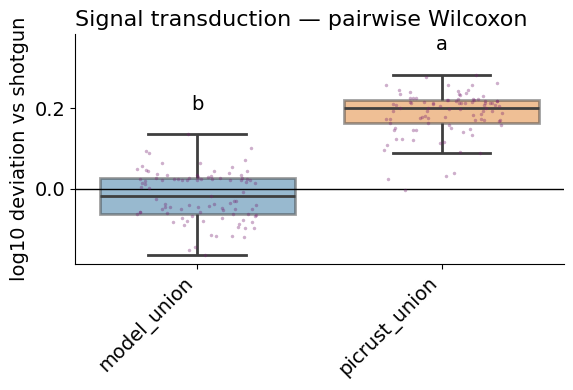

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:237: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


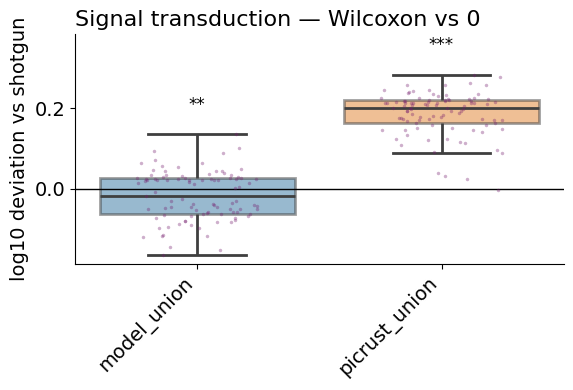

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


Processing pathway: Synaptic pathways


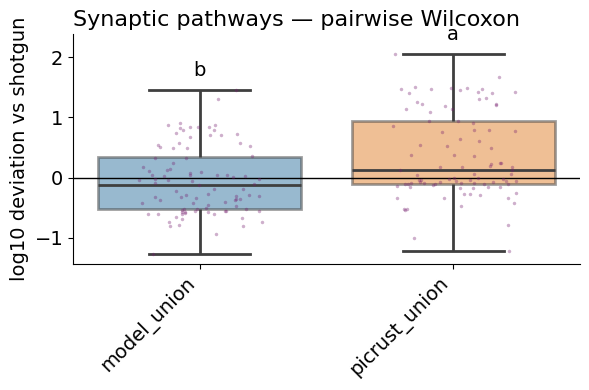

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:237: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


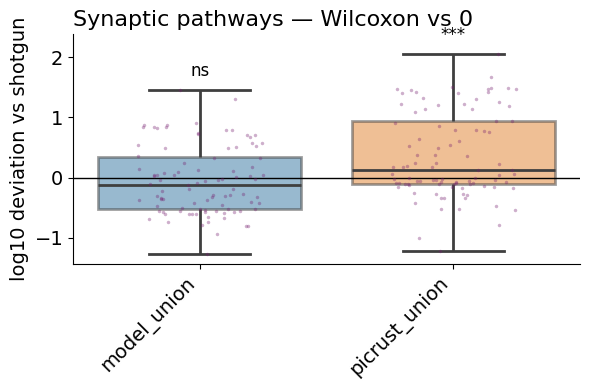

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


Processing pathway: Transcriptional regulation


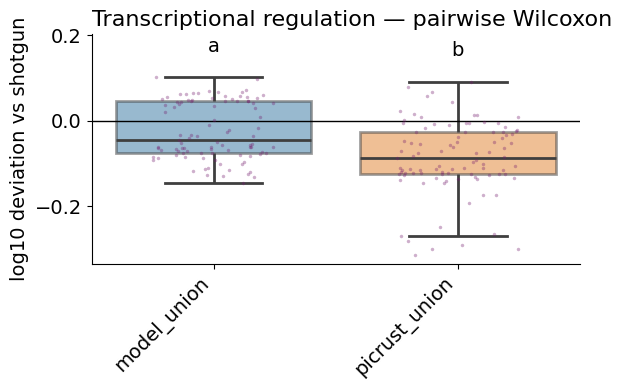

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:237: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


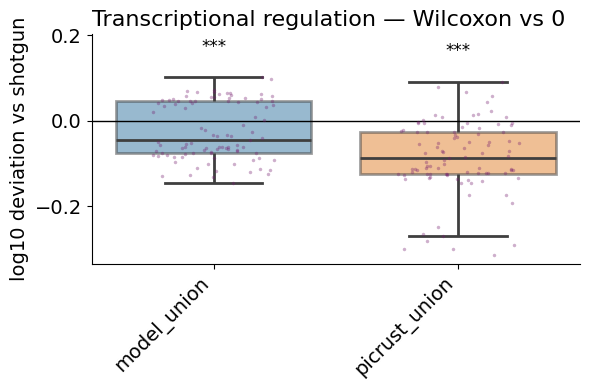

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


Processing pathway: Translation/ribosome


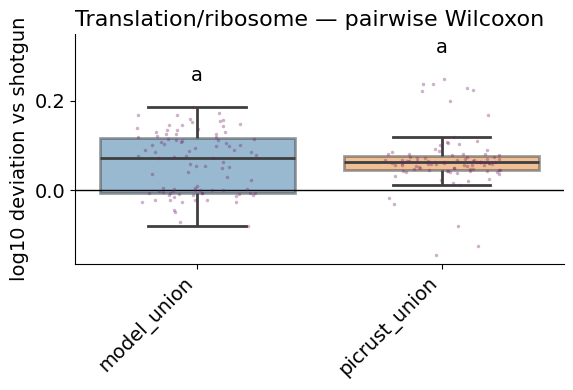

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:237: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


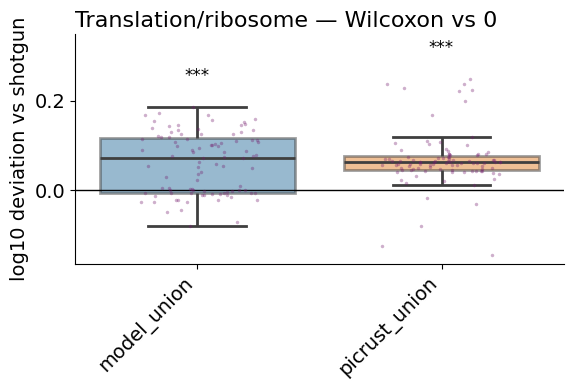

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


Processing pathway: Transport


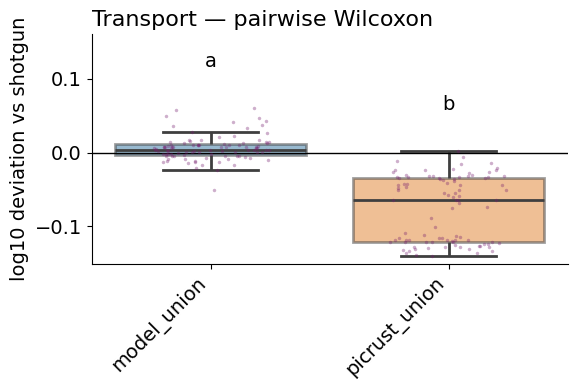

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:237: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


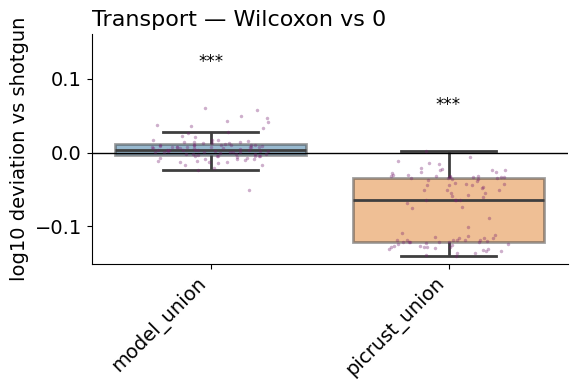

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


Processing pathway: Tryptophan metabolism


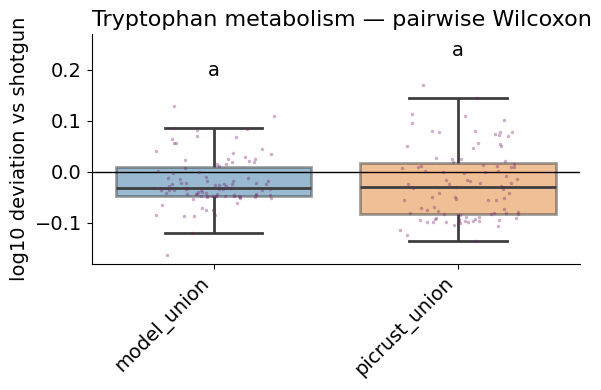

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:237: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


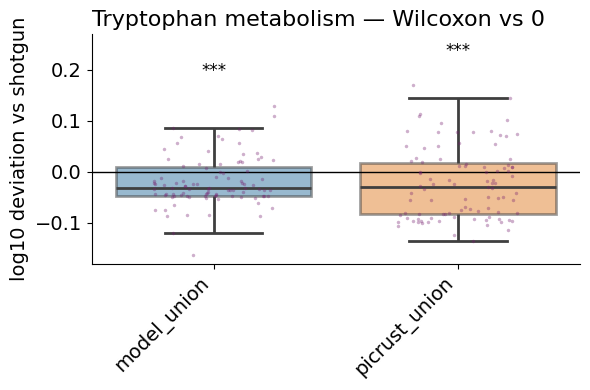

Processing pathway: Viral processes


/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


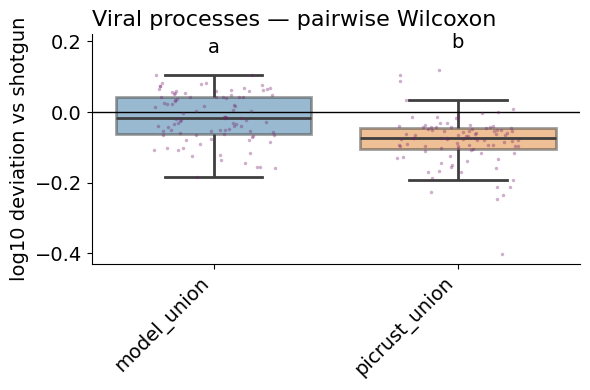

/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_4929/2215077623.py:237: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='cfg', y='deviation_log10',


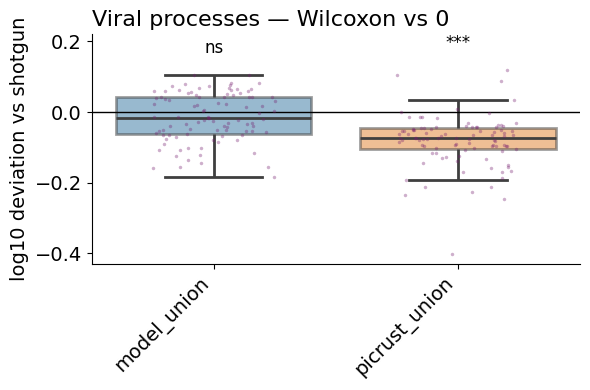

In [37]:
# Example: run on a single pathway (most frequent)
#top_pathway = dev_union['pathway'].value_counts().index[15]
cfg_order = ['model_raw', 'model_union']
if 'picrust_union' in dev_union['cfg'].unique():
    cfg_order.extend(['picrust_raw', 'picrust_union'])

for pathway in dev_union['pathway'].unique():
    print(f"Processing pathway: {pathway}")
    pairwise_df, vs0_df = plot_two_per_pathway(
        dev_union,
        pathway=pathway,
        cfg_order=cfg_order,
        kind='box',
        palette=None,
        min_pairs=10,
        min_n=10,
        sig_cutoff=0.05,
        y_max_cap=None,
        outdir=str(results_dir / 'pathway_stats'),
    )
    pairwise_df.head()


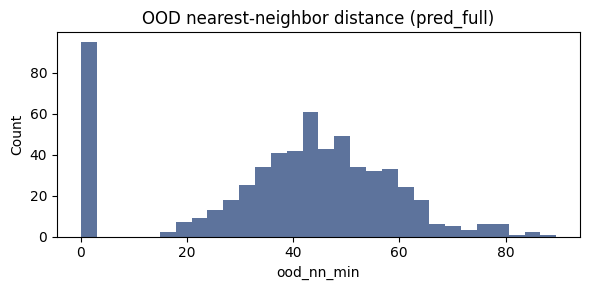

In [34]:
# Quick OOD diagnostic plot
plt.figure(figsize=(6, 3))
plt.hist(diag['ood_nn_min'], bins=30, color='#345084', alpha=0.8)
plt.title('OOD nearest-neighbor distance (pred_full)')
plt.xlabel('ood_nn_min')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


## Interpreting outputs
- `results/oof_clr.tsv`, `results/oof_tss.tsv`: out-of-fold predictions from nested CV
- `results/folds.tsv`: per-fold metrics + selected hyperparameters
- `results/summary.json` / `results/summary.tsv`: overall metrics
- `results/embed.joblib`: fitted embedding for k-mers
- `results/model.joblib`: final model artifact
- `results/pred_full.*`: predictions for all samples
- `results/pred_paired.metrics.tsv`: metrics when truth is provided
